# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [241]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import DirectedGraph
from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist


In [242]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [243]:
# Set Seed
SEED = 42

In [244]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ERGMS = os.path.join(OUTPUT_PATH, "ERGMs")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ERGMS)

In [245]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  7.81it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  3.04it/s]

Finished loading graph_power


In [246]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:01<00:11,  1.17s/it]

Finished loading WDN_1997
Finished loading WDN_1992


Loading GML WTW Files:  27%|██▋       | 3/11 [00:01<00:03,  2.42it/s]

Finished loading WDN_2000


Loading GML WTW Files:  45%|████▌     | 5/11 [00:02<00:02,  2.40it/s]

...

Finished loading WDN_2002
Finished loading WDN_1996


Loading GML WTW Files:  82%|████████▏ | 9/11 [00:03<00:00,  3.18it/s]

Finished loading WDN_1995


Loading GML WTW Files: 100%|██████████| 11/11 [00:04<00:00,  2.31it/s]

Finished loading WDN_1999
Finished loading WDN_2001


# I ERGMs

In [247]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x17a1c8110>,
 'graph_power': <networkx.classes.graph.Graph at 0x178afc350>}

In [248]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x17b451dd0>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x177e1cf50>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x17a7b78d0>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x17af7dbd0>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x1791d4790>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x17855c8d0>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x17c316490>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x17a701490>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x17c3044d0>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x17cd77650>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x17d002250>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

In [249]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

In [250]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.073686352073877, 'In-Out Assortativity': -0.07132955497657792, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.06970079872009402}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.04664740434092387, 'Out-In Assortativity': -0.05986979308699134, 'Out-Out Assortativity': -0.057603189205412644}, 'WDN_2000': {'In-In Assortativity': -0.06319707174975392, 'In-Out Assortativity': -0.06467170213846346, 'Out-In Assortativity': -0.06539073425903166, 'Out-Out Assortativity': -0.06730072607061888}, 'WDN_1998': {'In-In Assortativity': -0.06557057818395721, 'In-Out Assortativity': -0.06540616504184193, 'Out-In Assortativity': -0.06572057397949528, 'Out-Out Assortativity': -0.06583617855060356}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611883, 'In-Out Assortativity': -0.07622523439269806, 'Out-In Assortativity': -0.0802250161794805, 'Out-Out Assortativity': -0.07800143058821395}, 'WDN_1993':

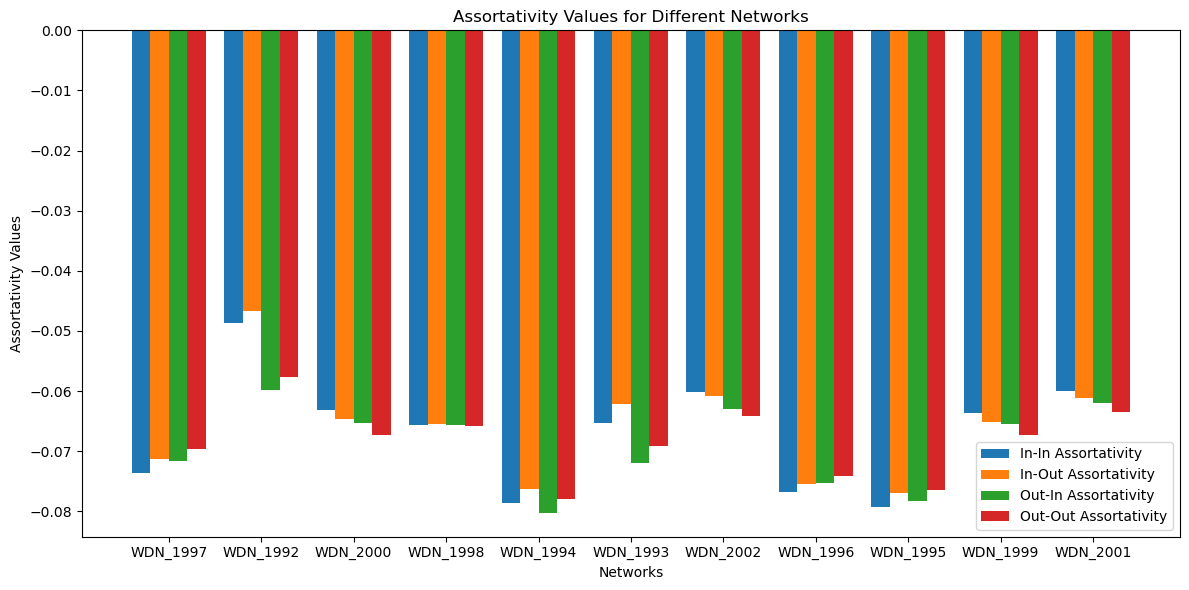

In [251]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

In [252]:
# Create undirected versions of the graph

graphs_wtn_undirected = {}
for graph_name, graph in graphs_wtn.items():
    graph_undirected = graph.to_undirected()

    graphs_wtn_undirected[graph_name] = graph_undirected

In [253]:
FIG_SIZE = (16, 12)
NODE_SIZE = 100

In [254]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x17b451dd0>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x177e1cf50>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x17a7b78d0>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x17af7dbd0>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x1791d4790>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x17855c8d0>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x17c316490>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x17a701490>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x17c3044d0>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x17cd77650>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x17d002250>}

In [255]:
graphs_wtn_undirected

{'WDN_1997': <networkx.classes.graph.Graph at 0x17cddb790>,
 'WDN_1992': <networkx.classes.graph.Graph at 0x17cd7f4d0>,
 'WDN_2000': <networkx.classes.graph.Graph at 0x17d2061d0>,
 'WDN_1998': <networkx.classes.graph.Graph at 0x17c512810>,
 'WDN_1994': <networkx.classes.graph.Graph at 0x17d5e1950>,
 'WDN_1993': <networkx.classes.graph.Graph at 0x17bae70d0>,
 'WDN_2002': <networkx.classes.graph.Graph at 0x17baecb50>,
 'WDN_1996': <networkx.classes.graph.Graph at 0x17bbaca50>,
 'WDN_1995': <networkx.classes.graph.Graph at 0x179b21e10>,
 'WDN_1999': <networkx.classes.graph.Graph at 0x17a9b5f90>,
 'WDN_2001': <networkx.classes.graph.Graph at 0x17b7ef990>}

In [256]:
nemtropy_directed_results = {}
nemtropy_undirected_results = {}

In [257]:
def to_entropy_graph(graph):
    # Extract necessary information from the NetworkX graph
    adj_weigh = nx.to_numpy_array(graph)  # Adjacency matrix
    edges = list(graph.edges())  # Edge list
    degrees = dict(graph.degree())  # Degree sequence (as a dictionary)
    strengths = dict(graph.degree(weight='weight'))  # Strength sequence (assuming weights are present)
    
    return adj_weigh, edges, degrees, strengths

In [258]:
def to_networkx_graph(adj_weigh):
    graph = nx.from_numpy_array(adj_weigh, create_using=nx.DiGraph)

    # Set edge attributes (weights) from the adjacency matrix
    edges = graph.edges(data=True)
    for (u, v, d) in edges:
        d['weight'] = adj_weigh[u][v]
    return graph

In [259]:
def plot_networkx(graph, graph_name, is_directed):

    # Plot the graph
    plt.figure(figsize=FIG_SIZE)

    # Set the layout for consistent plotting
    pos = nx.kamada_kawai_layout(graph)

    # Draw nodes and labels
    nx.draw(graph, pos, with_labels=True, node_size=NODE_SIZE, node_color='skyblue', font_weight='bold')

    # Draw edge labels with weights
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

    plt.title(f'{ "Undirected" if not is_directed else "Directed" } Weighted Graph of Network {graph_name} (networkx plot)')
    file_name=f'{ "undirected_" if not is_directed else "directed_"}weighted_graph_{graph_name}_networkx.png'
    complete_plot_filename=os.path.join(OUTPUT_PATH_ERGMS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

In [260]:
def plot_entropy_graph(adj_weigh, graph_name, is_directed):
    # Create a NetworkX graph from the weighted adjacency matrix
    graph = nx.from_numpy_array(adj_weigh, create_using=nx.DiGraph)

    # Set edge attributes (weights) from the adjacency matrix
    edges = graph.edges(data=True)
    for (u, v, d) in edges:
        d['weight'] = adj_weigh[u][v]

    # Plot the graph
    plt.figure(figsize=FIG_SIZE)

    pos = nx.spring_layout(graph, seed=SEED)  # Set the layout for consistent plotting

    # Draw nodes and labels
    nx.draw(graph, pos, with_labels=True, node_size=NODE_SIZE, node_color='skyblue', font_weight='bold')

    # Draw edge labels with weights
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

    plt.title(f'{ "Undirected" if not is_directed else "Directed" } Weighted Graph of Network {graph_name} (networkx plot)')
    file_name=f'{ "undirected_" if not is_directed else "directed_"}weighted_graph_{graph_name}_networkx.png'
    complete_plot_filename=os.path.join(OUTPUT_PATH_ERGMS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

In [261]:
for graph_name, graph in graphs_wtn.items():

    # Plot the networkx graph
    # plot_networkx(graph=graph, graph_name=graph_name, is_directed=True)

    # Extract necessary information from the NetworkX graph
    adj_weigh, edges, degrees, strengths = to_entropy_graph(graph)

    # Instantiate DirectedGraph with the extracted information
    nemtropy_graph = DirectedGraph(
        adjacency=adj_weigh,
        edgelist=edges,
        degree_sequence=np.array(list(degrees.values())),
        strength_sequence=np.array(list(strengths.values()))
    )

    # Plot the entropy graph
    # plot_entropy_graph(adj_weigh=adj_weigh, graph_name=graph_name, is_directed=True)
    
    # We can the see the graph sequence of the graph by tapping
    print("Out strength sequence ",nemtropy_graph.out_strength)
    print("In strength sequence ",nemtropy_graph.in_strength)

    # Create the fit
    fit = nemtropy_graph.solve_tool(model="crema",
                     method="newton",
                     initial_guess="random",
                     adjacency="dcm_exp",
                     method_adjacency="newton")

    nemtropy_directed_results[graph_name] = {'nemtropy_graph': nemtropy_graph  ,'fit': fit, 'error_degree': nemtropy_graph.error_degree, 'error_strength': nemtropy_graph.error_strength}
    print(nemtropy_graph.error_degree, nemtropy_graph.error_strength)

Out strength sequence  [2.50279029e+08 1.51110308e+10 4.61846567e+09 6.81711200e+07
 2.67190749e+10 2.21502936e+08 5.41374088e+10 4.91168703e+10
 7.49909115e+08 7.29857541e+08 1.87668938e+09 4.48724200e+09
 2.25759191e+08 5.02600422e+09 1.29821821e+11 2.60318865e+08
 5.41707901e+08 2.26150610e+07 1.02480718e+09 5.25837704e+10
 2.82353797e+09 4.23966182e+09 2.35580441e+08 9.52593690e+07
 5.48710564e+08 2.44952892e+09 1.13775298e+11 3.16235040e+07
 1.85608125e+08 2.50753772e+08 1.64791722e+10 2.04789199e+11
 1.21519771e+10 1.37451310e+07 2.07905204e+09 4.64450332e+09
 4.46854741e+09 3.05960474e+09 7.69311960e+08 1.28407149e+09
 4.06837602e+10 1.93593910e+07 8.93722920e+07 5.04968621e+09
 5.98755785e+09 6.02622009e+09 2.46597158e+09 3.91298119e+08
 5.33239834e+08 3.60664557e+10 5.37243648e+08 2.49628523e+11
 3.44346969e+09 1.78317524e+08 3.95918789e+11 1.43725953e+09
 9.81569645e+09 3.22718120e+07 3.94739741e+09 8.39709792e+08
 6.55107780e+07 5.97552384e+08 2.41601567e+08 3.36166761e+09
 

/usr/local/anaconda3/envs/network-science/lib/python3.11/site-packages/numba/core/utils.py:643: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",



solution error = 499348421659.7965
1.4725003438798012e-09 499348421659.7965
Out strength sequence  [5.64164710e+07 6.24782338e+09 2.88956492e+09 2.86005440e+07
 9.33957273e+09 6.88719500e+06 2.10538162e+10 3.03846311e+10
 6.93597580e+07 9.34456280e+08 7.92370638e+08 1.41043480e+09
 8.16695620e+07 2.65861489e+08 6.83905357e+10 1.20770037e+08
 8.31365780e+07 3.51032200e+06 3.84543557e+08 2.30325495e+10
 8.92662122e+08 1.42609327e+09 1.10649754e+08 5.88415860e+07
 1.58608416e+08 8.63400508e+08 5.96202792e+10 4.50548200e+06
 2.37063350e+07 1.09317145e+08 5.89295619e+09 5.72257013e+10
 5.53990945e+09 1.57934980e+07 8.31126212e+08 2.11459480e+09
 1.43185694e+09 8.07705137e+08 3.06135906e+08 5.00914086e+08
 2.17158479e+10 6.01044600e+06 6.11580300e+07 2.59085332e+09
 2.97988588e+09 2.97012301e+09 5.22737220e+08 2.97001310e+07
 2.50054620e+08 1.45721531e+10 7.75229410e+07 1.19649882e+11
 1.51565304e+09 1.15297980e+07 1.67041741e+11 6.00078443e+08
 4.60135770e+09 1.63824330e+07 1.55330203e+09 

In [262]:
nemtropy_directed_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x14b08df50>,
  'fit': None,
  'error_degree': 1.4725003438798012e-09,
  'error_strength': 499348421659.7965},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17c8c1810>,
  'fit': None,
  'error_degree': 4.40596181761066e-09,
  'error_strength': 341822731314.6583},
 'WDN_2000': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17d1e27d0>,
  'fit': None,
  'error_degree': 3.4728664388694597e-09,
  'error_strength': 591465719131.8215},
 'WDN_1998': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x179b287d0>,
  'fit': None,
  'error_degree': 5.290786475597997e-09,
  'error_strength': 537524168060.4795},
 'WDN_1994': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x14bb816d0>,
  'fit': None,
  'error_degree': 2.6924986684662144e-09,
  'error_strength': 406460811982.09595},
 'WDN_1993': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x179b70d

In [263]:
for graph_name, graph in graphs_wtn_undirected.items():

    # Plot the networkx graph
    # plot_networkx(graph=graph, graph_name=graph_name, is_directed=False)

    # Extract necessary information from the NetworkX graph
    adj_weigh, edges, degrees, strengths = to_entropy_graph(graph)

    # Instantiate DirectedGraph with the extracted information
    # TODO: Double check, if we might need UndirectedGraph
    nemtropy_graph = DirectedGraph(
        adjacency=adj_weigh,
        edgelist=edges,
        degree_sequence=np.array(list(degrees.values())),
        strength_sequence=np.array(list(strengths.values()))
    )

    # Plot the entropy graph
    # plot_entropy_graph(adj_weigh=adj_weigh, graph_name=graph_name, is_directed=False)

    # We can the see the graph sequence of the graph by tapping
    print("Out strength sequence ",nemtropy_graph.out_strength)
    print("In strength sequence ",nemtropy_graph.in_strength)

    # Create the fit
    fit = nemtropy_graph.solve_tool(model="crema",
                                    method="newton",
                                    initial_guess="random",
                                    adjacency="dcm_exp",
                                    method_adjacency="newton")

    nemtropy_undirected_results[graph_name] = {'nemtropy_graph': nemtropy_graph  ,'fit': fit, 'error_degree': nemtropy_graph.error_degree, 'error_strength': nemtropy_graph.error_strength}
    print(nemtropy_graph.error_degree, nemtropy_graph.error_strength)

Out strength sequence  [6.20970698e+08 8.68655112e+09 4.61846567e+09 6.81711200e+07
 2.92540077e+10 7.07953229e+08 5.86492209e+10 5.71170076e+10
 7.59558850e+08 1.60209303e+09 1.87668938e+09 7.00863074e+09
 9.76058514e+08 5.02600422e+09 1.48673970e+11 2.61291278e+08
 5.41707901e+08 2.26150610e+07 1.78889937e+09 6.25953327e+10
 2.03535578e+09 4.68252783e+09 7.27255384e+08 1.15513685e+08
 5.48710564e+08 1.53170408e+09 1.15391260e+11 2.41104856e+08
 2.10169523e+08 2.50753772e+08 1.62950816e+10 1.23053021e+11
 1.42758847e+10 5.49655170e+07 2.07905204e+09 4.51037724e+09
 3.25797288e+09 7.88907896e+09 3.29445535e+09 1.28407149e+09
 4.16037664e+10 1.93593910e+07 1.29493674e+08 5.04968621e+09
 4.54517108e+09 1.07395274e+10 2.78113938e+09 3.91298119e+08
 5.33239834e+08 3.10204725e+10 1.03718211e+09 2.39605088e+11
 1.11597755e+09 3.34653664e+08 3.67389748e+11 2.75118472e+09
 2.03731512e+10 1.60719007e+08 3.91413018e+09 6.38343290e+08
 6.55107780e+07 5.97552384e+08 2.41601567e+08 2.11941186e+09
 

In [264]:
nemtropy_undirected_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17d172dd0>,
  'fit': None,
  'error_degree': 1.3824035249854205e-09,
  'error_strength': 513956319197.34045},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x178ab1a10>,
  'fit': None,
  'error_degree': 3.721140728885075e-09,
  'error_strength': 352726669961.56256},
 'WDN_2000': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x179bc7490>,
  'fit': None,
  'error_degree': 3.2396201277151704e-09,
  'error_strength': 510712428693.58386},
 'WDN_1998': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x1780729d0>,
  'fit': None,
  'error_degree': 1.4504166756523773e-09,
  'error_strength': 514914625467.54004},
 'WDN_1994': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x1788c8910>,
  'fit': None,
  'error_degree': 1.6709122974134516e-09,
  'error_strength': 427560884299.6482},
 'WDN_1993': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

In [265]:
SAMPLE_SIZE = 2

In [266]:
for graph_name, results in nemtropy_directed_results.items():
    graph = results['nemtropy_graph']
    error_degree = results['error_degree']
    error_strength = results['error_strength']

    # Generate 30 ensembles copies using ensemble_sampler
    graph.ensemble_sampler(SAMPLE_SIZE, cpu_n=2, output_dir=f"{OUTPUT_PATH_ERGMS}/{graph_name}-directed-sample/")
    
    sampled_graphs = []
    assortativity_values = []
    for i in range(0, SAMPLE_SIZE, 1):
        # We read the edgelist
        edgelist_ens = np.loadtxt(f"{OUTPUT_PATH_ERGMS}/{graph_name}-directed-sample/{i}.txt")
        
        # and build the adjacency matrix
        ens_adj = build_adjacency_from_edgelist(edgelist = edgelist_ens,
                                                is_directed = True,
                                                is_sparse = False,
                                                is_weighted = True)
        
        sampled_graph = to_networkx_graph(ens_adj)
        sampled_graphs.append(sampled_graph)
        
        # measure strength assortativity
        assortativities = calculate_assortativity(sampled_graph)
        assortativity_values.append(assortativities)

    categories = list(assortativity_values[0].keys())

    # Initialize dictionaries to store mean and standard deviation for each category
    mean_values = {}
    std_values = {}
    
    # Loop through each category
    for category in categories:
        # Extract values for the current category across all dictionaries
        category_values = [data[category] for data in assortativity_values]
    
        # Calculate mean and standard
        mean = np.mean(category_values)
        std = np.std(category_values)
    
        # Store mean and standard deviation for the category
        mean_values[category] = mean
        std_values[category] = std

    results['samples'] = sampled_graphs
    results['assortativity_means'] = mean_values
    results['assortativity_stds'] = std_values

In [267]:
nemtropy_directed_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x14b08df50>,
  'fit': None,
  'error_degree': 1.4725003438798012e-09,
  'error_strength': 499348421659.7965,
  'samples': [<networkx.classes.digraph.DiGraph at 0x14ad068d0>,
  'assortativity_means': {'In-In Assortativity': -0.011459564027147373,
   'In-Out Assortativity': -0.005758417512754337,
   'Out-In Assortativity': -0.00554718039602768,
   'Out-Out Assortativity': -0.01254461053253193},
  'assortativity_stds': {'In-In Assortativity': 0.0002749815612664054,
   'In-Out Assortativity': 0.0005172319723628746,
   'Out-In Assortativity': 0.0005495644629865161,
   'Out-Out Assortativity': 7.46578562684291e-05}},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17c8c1810>,
  'fit': None,
  'error_degree': 4.40596181761066e-09,
  'error_strength': 341822731314.6583,
  'samples': [<networkx.classes.digraph.DiGraph at 0x17aa615d0>,
  'assortativity_means': {'In-In Assortativity': -0.015556403

In [268]:
for graph_name, results in nemtropy_undirected_results.items():
    # TODO:
    # Check if we not need UndirectedGraph
    # Check what Strength sequence is
    
    
    graph = results['nemtropy_graph']
    error_degree = results['error_degree']
    error_strength = results['error_strength']

    # Generate 30 ensembles copies using ensemble_sampler
    graph.ensemble_sampler(SAMPLE_SIZE, cpu_n=2, output_dir=f"{OUTPUT_PATH_ERGMS}/{graph_name}-undirected-sample/")

    sampled_graphs = []
    assortativity_values = []
    for i in range(0, SAMPLE_SIZE, 1):
        # We read the edgelist
        edgelist_ens = np.loadtxt(f"{OUTPUT_PATH_ERGMS}/{graph_name}-undirected-sample/{i}.txt")

        # and build the adjacency matrix
        ens_adj = build_adjacency_from_edgelist(edgelist = edgelist_ens,
                                                is_directed = True,
                                                is_sparse = False,
                                                is_weighted = True)

        sampled_graph = to_networkx_graph(ens_adj)
        sampled_graphs.append(sampled_graph)

        # measure strength assortativity
        assortativities = calculate_assortativity(sampled_graph)
        assortativity_values.append(assortativities)

    categories = list(assortativity_values[0].keys())

    # Initialize dictionaries to store mean and standard deviation for each category
    mean_values = {}
    std_values = {}

    # Loop through each category
    for category in categories:
        # Extract values for the current category across all dictionaries
        category_values = [data[category] for data in assortativity_values]

        # Calculate mean and standard
        mean = np.mean(category_values)
        std = np.std(category_values)

        # Store mean and standard deviation for the category
        mean_values[category] = mean
        std_values[category] = std

    results['samples'] = sampled_graphs
    results['assortativity_means'] = mean_values
    results['assortativity_stds'] = std_values

In [269]:
nemtropy_undirected_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x17d172dd0>,
  'fit': None,
  'error_degree': 1.3824035249854205e-09,
  'error_strength': 513956319197.34045,
  'samples': [<networkx.classes.digraph.DiGraph at 0x17d20b490>,
  'assortativity_means': {'In-In Assortativity': -0.01728444751202447,
   'In-Out Assortativity': -0.011795746053129393,
   'Out-In Assortativity': -0.01176475667801342,
   'Out-Out Assortativity': -0.015102902501681215},
  'assortativity_stds': {'In-In Assortativity': 0.003383049487656161,
   'In-Out Assortativity': 0.0010604913136164906,
   'Out-In Assortativity': 0.001273539505848749,
   'Out-Out Assortativity': 0.0008006928891782922}},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x178ab1a10>,
  'fit': None,
  'error_degree': 3.721140728885075e-09,
  'error_strength': 352726669961.56256,
  'samples': [<networkx.classes.digraph.DiGraph at 0x173440b10>,
  'assortativity_means': {'In-In Assortativity': -0.0261521

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

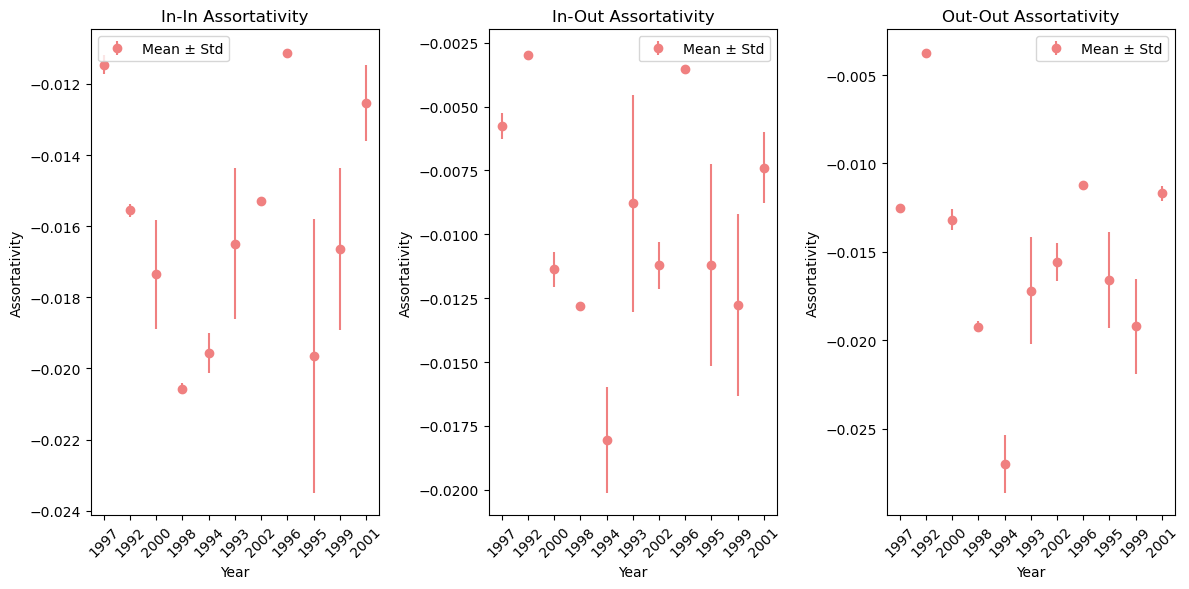

In [270]:
# Years
years = list(nemtropy_directed_results.keys())
x = np.arange(len(years))

# Assortativity pairs
assortativity_pairs = ['In-In Assortativity', 'In-Out Assortativity', 'Out-Out Assortativity']

# Plotting
plt.figure(figsize=(12, 6))

for i, pair in enumerate(assortativity_pairs):
    plt.subplot(1, 3, i + 1)
    sample_means = [nemtropy_directed_results[year]['assortativity_means'][pair] for year in years]
    sample_std = [nemtropy_directed_results[year]['assortativity_stds'][pair] for year in years]

    plt.errorbar(x, sample_means, yerr=sample_std, fmt='o', label='Mean ± Std', color=COLOR_RED)
    plt.xticks(x, [year[-4:] for year in years], rotation=45)
    plt.title(f'{pair}')
    plt.xlabel('Year')
    plt.ylabel('Assortativity')
    plt.legend()

plt.tight_layout()
plt.show()

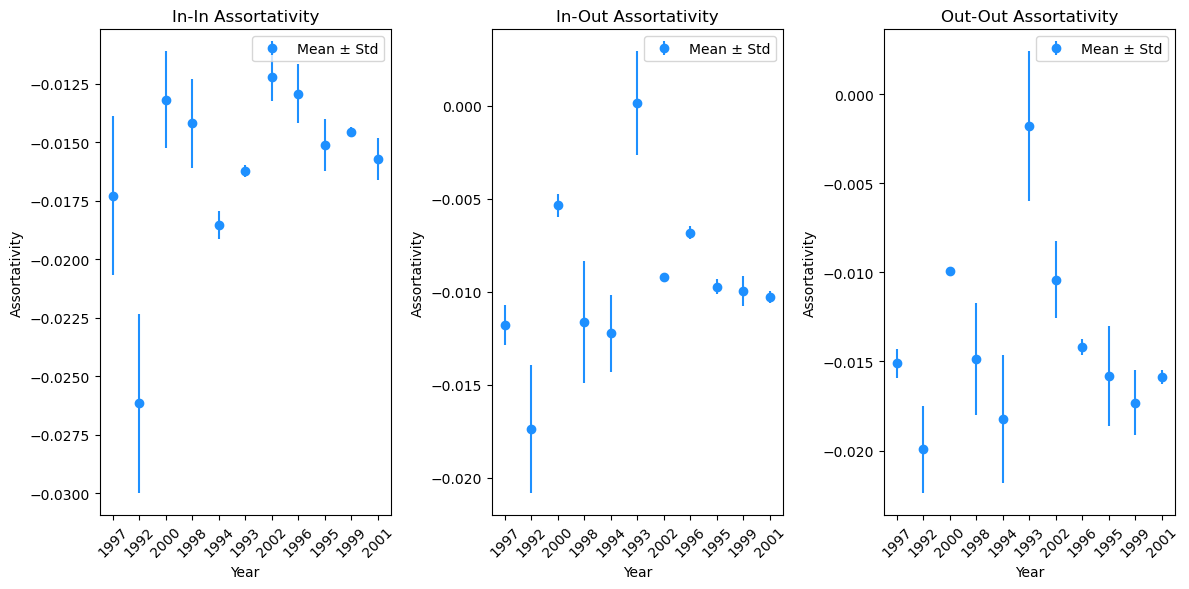

In [271]:
# Years
years = list(nemtropy_undirected_results.keys())
x = np.arange(len(years))

# Assortativity pairs
assortativity_pairs = ['In-In Assortativity', 'In-Out Assortativity', 'Out-Out Assortativity']

# Plotting
plt.figure(figsize=(12, 6))

for i, pair in enumerate(assortativity_pairs):
    plt.subplot(1, 3, i + 1)
    sample_means = [nemtropy_undirected_results[year]['assortativity_means'][pair] for year in years]
    sample_std = [nemtropy_undirected_results[year]['assortativity_stds'][pair] for year in years]

    plt.errorbar(x, sample_means, yerr=sample_std, fmt='o', label='Mean ± Std', color=COLOR_BLUE)
    plt.xticks(x, [year[-4:] for year in years], rotation=45)
    plt.title(f'{pair}')
    plt.xlabel('Year')
    plt.ylabel('Assortativity')
    plt.legend()

plt.tight_layout()
plt.show()

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`